# Profitability and repeatability diagnostics

This notebook implements NB11 from `steady-vault-plan-01.md`. It tests three
pre-registered, point-in-time selection arms against the same equal-weight
portfolio construction:

* **P0**: positive observed annualised growth in the available 60/30/14-day
  history;
* **P1**: at least 15% annualised growth and positive measured returns in both
  halves of that available history; and
* **P2**: P1 plus positive measured weeks in at least 70% of weekly outcomes,
  no more than 50% of positive cadence-matched gains from the largest gain, and
  positive growth after removing that gain.

The windows are selected in the fixed order 60, 30, 14 days. A fallback is
allowed when the longer window has no usable observed interval. The selected
window, actual span, observed intervals and missing repeatability evidence are
saved for every row. This is deliberately a diagnostic, not a search for the
best threshold. Share-price growth is used as the available NAV growth proxy;
no generic slippage, liquidation cost or external fee is invented.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
NB10 = PROJECT_DIR / "_artifacts-steady-vault-data"
OUT = PROJECT_DIR / "_artifacts-profitability-repeatability"
OUT.mkdir(exist_ok=True)

FEATURES = pd.read_parquet(REWRITE / "features.parquet")
FEATURES["date"] = pd.to_datetime(FEATURES.date).dt.normalize()
FEATURES["address"] = FEATURES.address.astype(str).str.lower()
FEATURES = FEATURES[FEATURES.eligible].copy()
OBS = pd.read_parquet(REWRITE / "observations.parquet")
OBS["address"] = OBS.address.astype(str).str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
OBS = OBS[OBS.is_fresh & OBS.share_price.gt(0)].sort_values(["address", "timestamp"])
LABELS = pd.read_parquet(REWRITE / "labels.parquet", columns=["date", "address", "eligible"] + [f"forward_log_growth_raw_{h}" for h in (14, 30, 60)])
LABELS["date"] = pd.to_datetime(LABELS.date).dt.normalize()
LABELS["address"] = LABELS.address.astype(str).str.lower()
METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.astype(str).str.lower()
METADATA = METADATA.drop_duplicates("address").set_index("address")

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
universe_json = json.loads(UNIVERSE_CACHE.read_text())
universe_items = universe_json.get("vaults", universe_json) if isinstance(universe_json, dict) else universe_json
A0B_ALLOWLIST = {str(item["address"]).lower() for item in universe_items if "address" in item}
A0B_ALLOWLIST.discard("0x5290ab34acb59cfe1371baa5782eba14433d308f")

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
INITIAL_CASH = 150_000.0
TARGET_DEPLOYMENT = 0.98
MAX_WEIGHT = 0.20
MAX_TVL_FRACTION = 0.33
MAX_NAMES = 20
WINDOWS = (60, 30, 14)
EXECUTION_EVERY_DAYS = 2

print({"features": FEATURES.shape, "observations": OBS.shape, "labels": LABELS.shape, "a0b_allowlist": len(A0B_ALLOWLIST), "periods": PERIODS})


{'features': (104618, 410), 'observations': (487738, 9), 'labels': (104618, 6), 'a0b_allowlist': 338, 'periods': {'hyper_ai': (Timestamp('2026-01-01 00:00:00'), Timestamp('2026-07-08 00:00:00')), 'full': (Timestamp('2025-09-13 00:00:00'), Timestamp('2026-09-12 00:00:00'))}}


## Causal history metrics and fallback policy

The feature panel is already calculated using marks known at each decision
date. The additional metrics below only inspect observations with timestamps
at or before the feature row's `last_observation_ts`; they never use the
forward labels. A 60-day feature is preferred, then 30-day, then 14-day.
`estimated_net_growth` is the annualised growth over the actual observed span,
so sparse rows disclose their shorter or longer span rather than pretending
that missing days were zero returns. A row with no repeatability outcomes is
marked provisional and cannot pass P2.


In [2]:
def finite(value):
    return pd.notna(value) and np.isfinite(float(value))


def history_window(row):
    for window in WINDOWS:
        growth = getattr(row, f"interval_log_growth_{window}", np.nan)
        covered = getattr(row, f"observed_covered_days_{window}", np.nan)
        count = getattr(row, f"observed_interval_count_{window}", np.nan)
        if finite(growth) and finite(covered) and float(covered) > 0 and float(count) >= 1:
            return window
    return np.nan


def _segment_return(frame):
    if len(frame) < 2:
        return np.nan
    prices = pd.to_numeric(frame.share_price, errors="coerce").dropna()
    if len(prices) < 2 or (prices <= 0).any():
        return np.nan
    return float(prices.iloc[-1] / prices.iloc[0] - 1)


def causal_history_metrics(row, vault):
    # Calculate diagnostics from observations known at this decision point.

    window = history_window(row)
    if not finite(window):
        return {"history_window_days": np.nan, "history_status": "no_usable_window"}
    cutoff = pd.Timestamp(row.last_observation_ts)
    start = cutoff - pd.Timedelta(days=int(window))
    timestamps = vault.timestamp.to_numpy(dtype="datetime64[ns]")
    left = int(np.searchsorted(timestamps, np.datetime64(start), side="right"))
    right = int(np.searchsorted(timestamps, np.datetime64(cutoff), side="right"))
    left = max(left - 1, 0)  # Preserve the last mark before the window boundary.
    history = vault.iloc[left:right].copy()
    history = history.drop_duplicates("timestamp").sort_values("timestamp")
    if len(history) < 2:
        return {"history_window_days": int(window), "history_status": "insufficient_intervals"}
    prices = pd.to_numeric(history.share_price, errors="coerce")
    log_returns = np.log(prices / prices.shift(1)).dropna()
    durations = history.timestamp.diff().dt.total_seconds().div(86400).iloc[1:]
    valid = log_returns.notna() & durations.gt(0)
    log_returns = log_returns[valid]
    durations = durations[valid]
    if log_returns.empty:
        return {"history_window_days": int(window), "history_status": "invalid_intervals"}
    first_timestamp = history.timestamp.iloc[0]
    last_timestamp = history.timestamp.iloc[-1]
    actual_span = max((last_timestamp - first_timestamp).total_seconds() / 86400, 1e-9)
    total_log_growth = float(log_returns.sum())
    estimated_growth = float(np.expm1(total_log_growth * 365.0 / actual_span))
    midpoint = last_timestamp - pd.Timedelta(days=float(window) / 2)
    first_half = history[history.timestamp.le(midpoint)]
    second_half = history[history.timestamp.ge(midpoint)]

    # Cadence-matched events: only intervals of at most ten days enter the
    # repeatability test. A multi-week gap is not silently treated as a week.
    events = []
    anchor_timestamp = history.timestamp.iloc[0]
    anchor_price = float(history.share_price.iloc[0])
    for item in history.iloc[1:].itertuples():
        duration = (item.timestamp - anchor_timestamp).total_seconds() / 86400
        if duration < 5:
            continue
        if duration <= 10:
            if anchor_price > 0 and float(item.share_price) > 0:
                events.append({"duration_days": duration, "log_return": math.log(float(item.share_price) / anchor_price)})
            anchor_timestamp = item.timestamp
            anchor_price = float(item.share_price)
        else:
            anchor_timestamp = item.timestamp
            anchor_price = float(item.share_price)
    event_returns = np.array([item["log_return"] for item in events], dtype=float)
    positive = event_returns[event_returns > 0]
    if len(event_returns):
        positive_week_share = float(np.mean(event_returns > 0))
        weekly_outcomes = int(len(event_returns))
    else:
        positive_week_share = np.nan
        weekly_outcomes = 0
    positive_sum = float(positive.sum()) if len(positive) else 0.0
    largest_positive_share = float(positive.max() / positive_sum) if positive_sum > 0 else np.nan
    best_event_removed_growth = float(np.expm1((total_log_growth - (positive.max() if len(positive) else 0.0)) * 365.0 / actual_span))
    downside = np.minimum(log_returns.to_numpy(dtype=float), 0.0)
    # Annualise by elapsed observed time. Dividing by interval count would
    # make a sparse weekly path look safer than the same path sampled daily.
    annualised_downside = float(np.sqrt(np.sum(downside ** 2) * 365.0 / actual_span)) if len(downside) else np.nan
    return {
        "history_window_days": int(window),
        "history_actual_span_days": float(actual_span),
        "history_observed_intervals": int(len(log_returns)),
        "estimated_net_growth": estimated_growth,
        "first_half_return": _segment_return(first_half),
        "second_half_return": _segment_return(second_half),
        "annualised_downside": annualised_downside,
        "max_event_log_return": float(event_returns.max()) if len(event_returns) else np.nan,
        "weekly_outcomes": weekly_outcomes,
        "positive_observed_week_share": positive_week_share,
        "largest_positive_event_share": largest_positive_share,
        "best_event_removed_growth": best_event_removed_growth,
        "history_status": "measured" if len(event_returns) else "no_repeatability_outcomes",
    }


obs_by_address = {address: frame.reset_index(drop=True) for address, frame in OBS.groupby("address", sort=False)}
metric_rows = []
metric_columns = ["date", "address", "last_observation_ts"] + [
    column
    for window in WINDOWS
    for column in (f"interval_log_growth_{window}", f"observed_covered_days_{window}", f"observed_interval_count_{window}")
]
for row in FEATURES[metric_columns].itertuples(index=False):
    vault = obs_by_address.get(row.address)
    metrics = causal_history_metrics(row, vault) if vault is not None else {"history_window_days": np.nan, "history_status": "missing_observations"}
    metric_rows.append({"date": row.date, "address": row.address, **metrics})
HISTORY = pd.DataFrame(metric_rows)
SIGNALS = FEATURES.merge(HISTORY, on=["date", "address"], how="left", validate="one_to_one")
SIGNALS["positive_halves"] = SIGNALS.first_half_return.gt(0) & SIGNALS.second_half_return.gt(0)
SIGNALS["growth_excess_15"] = SIGNALS.estimated_net_growth.ge(0.15)
SIGNALS["p0"] = SIGNALS.estimated_net_growth.gt(0)
SIGNALS["p1"] = SIGNALS.p0 & SIGNALS.growth_excess_15 & SIGNALS.positive_halves
SIGNALS["repeatability_missing"] = SIGNALS.weekly_outcomes.fillna(0).eq(0) | SIGNALS.positive_observed_week_share.isna()
SIGNALS["p2"] = SIGNALS.p1 & ~SIGNALS.repeatability_missing & SIGNALS.positive_observed_week_share.ge(0.70) & SIGNALS.largest_positive_event_share.le(0.50) & SIGNALS.best_event_removed_growth.gt(0)
SIGNALS["incumbent"] = SIGNALS.incumbent_score.notna() & SIGNALS.incumbent_return_gate.gt(-0.16)
SIGNALS["p0_reason"] = np.select([SIGNALS.p0, SIGNALS.estimated_net_growth.notna()], ["positive_growth", "no_positive_growth_evidence"], default="no_history")
SIGNALS["p1_reason"] = np.select([SIGNALS.p1, SIGNALS.p0 & ~SIGNALS.positive_halves, SIGNALS.p0], ["growth_and_positive_halves", "missing_or_nonpositive_half", "below_15pct_growth"], default="no_positive_growth")
SIGNALS["p2_reason"] = np.select([SIGNALS.p2, SIGNALS.p1 & SIGNALS.repeatability_missing, SIGNALS.p1], ["repeatable_and_event_robust", "provisional_missing_weekly_evidence", "repeatability_threshold_failed"], default="parent_p1_failed")
SIGNALS["ranking_growth"] = SIGNALS.estimated_net_growth.clip(lower=-1, upper=0.30)
SIGNALS["ranking_downside"] = SIGNALS.annualised_downside.fillna(np.inf)
SIGNALS.to_parquet(OUT / "point_in_time-selection-signals.parquet", index=False)
SIGNALS[["date", "address", "history_window_days", "history_actual_span_days", "history_observed_intervals", "history_status", "p0", "p1", "p2", "p0_reason", "p1_reason", "p2_reason", "repeatability_missing"]].to_csv(OUT / "eligibility-reasons.csv", index=False)
display(SIGNALS[["history_window_days", "history_status", "p0", "p1", "p2", "repeatability_missing"]].value_counts(dropna=False).rename("rows").reset_index())


,history_window_days,history_status,p0,p1,p2,repeatability_missing,rows
0,60,measured,False,False,False,False,52371
1,60,measured,True,False,False,False,28134
2,60,measured,True,True,False,False,13758
3,60,measured,True,True,True,False,7504
4,60,no_repeatability_outcomes,False,False,False,True,1509
5,60,no_repeatability_outcomes,True,False,False,True,829
6,60,no_repeatability_outcomes,True,True,False,True,513


## Frozen selection arms and universe sensitivity

Selection is rebuilt independently for every date. Names are sorted by capped
growth, lower downside and address, then at most 20 are requested. P0/P1/P2
are run on both the full research panel and the retrospective A0b allowlist.
The allowlist is retained as a sensitivity because it is a current snapshot,
not a point-in-time universe. The `incumbent` arm is a sizing-only reference:
it uses the incumbent gate and score but the same broad equal-weight/cap/cash
rules as these arms. It does not claim to reproduce the production A0b six-slot
inverse-variance simulator.


In [3]:
ARMS = ("P0", "P1", "P2", "incumbent")


def selection_for(frame, arm):
    if arm == "P0":
        eligible = frame.p0.fillna(False)
    elif arm == "P1":
        eligible = frame.p1.fillna(False)
    elif arm == "P2":
        eligible = frame.p2.fillna(False)
    else:
        eligible = frame.incumbent.fillna(False)
    output = frame.copy()
    output["qualified"] = eligible
    output["selected"] = False
    output["selection_rank"] = np.nan
    for date, day_index in output.groupby("date", sort=True).groups.items():
        day = output.loc[day_index]
        pool = day[day.qualified].copy()
        if arm == "incumbent":
            sort_columns, ascending = ["incumbent_score", "ranking_downside", "address"], [False, True, True]
        else:
            sort_columns, ascending = ["ranking_growth", "ranking_downside", "address"], [False, True, True]
        pool = pool.sort_values(sort_columns, ascending=ascending, kind="stable").head(MAX_NAMES)
        output.loc[pool.index, "selected"] = True
        output.loc[pool.index, "selection_rank"] = np.arange(1, len(pool) + 1)
    return output


UNIVERSES = {"full_panel": set(SIGNALS.address.unique()), "a0b_allowlist": A0B_ALLOWLIST}
SELECTIONS = {}
selection_summaries = []
for universe_name, addresses in UNIVERSES.items():
    universe_frame = SIGNALS[SIGNALS.address.isin(addresses)].copy()
    for arm in ARMS:
        selected = selection_for(universe_frame, arm)
        selected["universe"] = universe_name
        selected["arm"] = arm
        SELECTIONS[(universe_name, arm)] = selected
        selected.to_parquet(OUT / f"selection-{universe_name}-{arm}.parquet", index=False)
        selection_summaries.append({"universe": universe_name, "arm": arm, "rows": len(selected), "dates": int(selected.date.nunique()), "qualified_rows": int(selected.qualified.sum()), "selected_rows": int(selected.selected.sum()), "selected_dates": int(selected.loc[selected.selected, "date"].nunique())})
selection_summary = pd.DataFrame(selection_summaries)
selection_summary.to_csv(OUT / "selection-summary.csv", index=False)
display(selection_summary)


,universe,arm,rows,dates,qualified_rows,selected_rows,selected_dates
0,full_panel,P0,104618,545,50738,10900,545
1,full_panel,P1,104618,545,21775,10561,545
2,full_panel,P2,104618,545,7504,7191,545
3,full_panel,incumbent,104618,545,23085,9996,545
4,a0b_allowlist,P0,61891,545,31233,10685,545
5,a0b_allowlist,P1,61891,545,13701,9384,545
6,a0b_allowlist,P2,61891,545,4491,4458,538
7,a0b_allowlist,incumbent,61891,545,13127,8056,545


## Equal-weight capped portfolio replay

The replay uses daily marks and signals, with an execution every second day to
match the A0b cadence. Fresh share-price observations are carried forward for
valuation, while selection only uses the point-in-time feature row. Target
investment is 98% of equity, each requested name is capped at 20% of equity and
at 33% of its observed TVL, and any unused amount remains cash. There is no
forced liquidation fee or invented slippage.
Current metadata rows explicitly reporting a redemption block remain held and
consume capital; the metadata is a present-day operational snapshot and is
reported as such rather than treated as historical knowledge.


In [4]:
def build_daily_marks(observations, dates):
    marks = observations.assign(calendar_date=observations.timestamp.dt.normalize()).groupby(["calendar_date", "address"]).share_price.last().unstack("address")
    # Keep a genuinely available mark before a cold-start date. Reindexing
    # directly to dates discards that mark and leaves the portfolio in cash
    # until the first in-period publication.
    index = marks.index.union(dates).sort_values()
    return marks.reindex(index).sort_index().ffill().reindex(dates)


BLOCKED = set()
if "redemption_closed_reason" in METADATA:
    blocked_values = METADATA.redemption_closed_reason.astype("string")
    BLOCKED = set(METADATA.index[blocked_values.notna() & blocked_values.str.strip().ne("")])


def replay(selection, start, end, universe_name, arm):
    dates = pd.date_range(start, end, freq="D")
    marks = build_daily_marks(OBS, dates)
    execution_dates = set(dates[::EXECUTION_EVERY_DAYS])
    rows, target_rows = [], []
    cash = INITIAL_CASH
    units = {}
    last_prices = {}
    for date in dates:
        day_prices = marks.loc[date] if date in marks.index else pd.Series(dtype=float)
        for address, price in day_prices.dropna().items():
            last_prices[address] = float(price)
        marked = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        equity = cash + sum(marked.values())
        target = dict(marked)
        turnover = 0.0
        if date in execution_dates:
            day = selection[selection.date.eq(date)].set_index("address")
            chosen = day[day.selected].copy()
            target = {address: value for address, value in marked.items() if address in BLOCKED}
            investable = max(equity * TARGET_DEPLOYMENT, 0.0)
            if len(chosen):
                requested = investable / len(chosen)
                for address, item in chosen.iterrows():
                    if address in BLOCKED and address in target:
                        continue
                    capacity = min(equity * MAX_WEIGHT, MAX_TVL_FRACTION * float(item.tvl_current))
                    accepted = max(min(requested, capacity), 0.0) if finite(item.tvl_current) else 0.0
                    if address in last_prices:
                        target[address] = accepted
                    target_rows.append({"date": date, "universe": universe_name, "arm": arm, "address": address, "qualified": bool(item.qualified), "selected": True, "selection_rank": item.selection_rank, "requested_dollars": requested, "accepted_dollars": accepted, "cap_binding": accepted + 1e-8 < requested, "tvl_current": item.tvl_current, "blocked": address in BLOCKED})
            # Existing blocked positions are deliberately retained. Other
            # names absent from the selected set are redeemed on this
            # execution date. No fees are added to the share-price NAV.
            cash = max(equity - sum(target.values()), 0.0)
            turnover = float(sum(abs(target.get(address, 0) - marked.get(address, 0)) for address in set(target) | set(marked)))
            units = {address: value / last_prices[address] for address, value in target.items() if value > 0 and address in last_prices}
            equity = cash + sum(value for address, value in target.items() if address in last_prices)
        invested = max(equity - cash, 0.0)
        # Effective positions are normalised over the invested basket. Cash
        # is reported separately and must not make a diversified basket look
        # as if it had more positions than it actually holds.
        weights = pd.Series({address: value / invested for address, value in target.items()}) if invested > 0 else pd.Series(dtype=float)
        rows.append({"date": date, "equity": equity, "cash": cash, "cash_fraction": cash / equity if equity else np.nan, "invested": invested, "n_positions": len(target), "effective_positions": float(1 / (weights.pow(2).sum())) if len(weights) and weights.pow(2).sum() > 0 else 0.0, "turnover": turnover, "execution_date": date in execution_dates, "blocked_positions": int(sum(address in BLOCKED for address in target)), "universe": universe_name, "arm": arm})
    curve = pd.DataFrame(rows)
    curve["return"] = curve.equity.pct_change()
    curve["drawdown"] = curve.equity / curve.equity.cummax() - 1
    trades = pd.DataFrame(target_rows)
    return curve, trades


def metrics(curve):
    if curve.empty:
        return {}
    returns = curve["return"].dropna()
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    std = returns.std(ddof=1)
    return {"start": curve.date.iloc[0], "end": curve.date.iloc[-1], "final_equity": float(curve.equity.iloc[-1]), "cagr": float((curve.equity.iloc[-1] / curve.equity.iloc[0]) ** (365.0 / span_days) - 1), "volatility": float(std * math.sqrt(365.0)) if finite(std) else np.nan, "sharpe": float(returns.mean() / std * math.sqrt(365.0)) if finite(std) and std > 0 else np.nan, "max_drawdown": float(curve.drawdown.min()), "ulcer": float(np.sqrt(np.mean(curve.drawdown.pow(2)))), "mean_cash_fraction": float(curve.cash_fraction.mean()), "mean_positions": float(curve.n_positions.mean()), "mean_effective_positions": float(curve.effective_positions.mean()), "mean_turnover": float(curve.turnover.mean()), "blocked_position_days": int(curve.blocked_positions.sum())}


backtest_rows = []
for (universe_name, arm), selection in SELECTIONS.items():
    for period_name, (start, end) in PERIODS.items():
        curve, trades = replay(selection, start, end, universe_name, arm)
        curve.to_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet", index=False)
        trades.to_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet", index=False)
        backtest_rows.append({"universe": universe_name, "arm": arm, "period": period_name, **metrics(curve)})
backtest_metrics = pd.DataFrame(backtest_rows)
backtest_metrics.to_csv(OUT / "backtest-metrics.csv", index=False)
display(backtest_metrics.round(4))


,universe,arm,period,start,end,final_equity,cagr,volatility,sharpe,max_drawdown,ulcer,mean_cash_fraction,mean_positions,mean_effective_positions,mean_turnover,blocked_position_days
0,full_panel,P0,hyper_ai,2026-01-01,2026-07-08,143268.6394,-0.0853,0.1217,-0.6716,-0.0999,0.0608,0.1652,20.0000,18.6062,21382.5274,0
1,full_panel,P0,full,2025-09-13,2026-09-12,140482.3646,-0.0636,0.1120,-0.5307,-0.1374,0.0838,0.1444,20.0000,18.8512,18672.2080,0
2,full_panel,P1,hyper_ai,2026-01-01,2026-07-08,152243.1372,0.0292,0.0998,0.3387,-0.0543,0.0262,0.1675,20.0000,18.5886,25280.5357,0
3,full_panel,P1,full,2025-09-13,2026-09-12,164926.7055,0.0998,0.1288,0.8015,-0.0544,0.0268,0.1598,20.0000,18.6501,23386.0258,0
4,full_panel,P2,hyper_ai,2026-01-01,2026-07-08,165684.4324,0.2130,0.1619,1.2736,-0.0685,0.0333,0.2614,15.9259,14.1020,40469.7781,0
5,full_panel,P2,full,2025-09-13,2026-09-12,157018.5729,0.0469,0.1814,0.3444,-0.1224,0.0482,0.2580,14.7342,13.0654,34433.0728,0
6,full_panel,incumbent,hyper_ai,2026-01-01,2026-07-08,137222.8964,-0.1587,0.1580,-1.0149,-0.1228,0.0680,0.0656,20.0000,19.5690,15162.0674,0
7,full_panel,incumbent,full,2025-09-13,2026-09-12,102333.8800,-0.3185,0.1883,-1.9409,-0.3422,0.2293,0.0690,20.0000,19.5994,11232.1327,0
8,a0b_allowlist,P0,hyper_ai,2026-01-01,2026-07-08,133506.5585,-0.2024,0.1089,-2.0219,-0.1478,0.1111,0.1955,20.0000,18.4951,18520.1396,0
9,a0b_allowlist,P0,full,2025-09-13,2026-09-12,139047.4582,-0.0732,0.1477,-0.4422,-0.1790,0.1236,0.1743,20.0000,18.6595,17136.7984,0


## Forward selected-versus-rejected diagnostics

These are matched-row diagnostics, not an additional fitted selection rule.
For each arm and universe, selected and rejected rows are compared only where
the corresponding 14/30/60-day outcome exists. The outcomes are not used by
the selection code, and overlapping horizons are reported separately rather
than pooled as independent samples.


In [5]:
forward_rows = []
for (universe_name, arm), selection in SELECTIONS.items():
    joined = selection[["date", "address", "selected", "qualified", "history_window_days", "history_actual_span_days"]].merge(LABELS, on=["date", "address"], how="left", validate="one_to_one")
    for period_name, (start, end) in PERIODS.items():
        period = joined[joined.date.between(start, end)].copy()
        for horizon in (14, 30, 60):
            column = f"forward_log_growth_raw_{horizon}"
            valid = period[period[column].notna()].copy()
            for selected_status, group in valid.groupby("selected"):
                forward_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "horizon_days": horizon, "selected": bool(selected_status), "rows": len(group), "dates": int(group.date.nunique()), "mean_log_growth": float(group[column].mean()) if len(group) else np.nan, "median_log_growth": float(group[column].median()) if len(group) else np.nan, "positive_fraction": float((group[column] > 0).mean()) if len(group) else np.nan, "mean_simple_growth": float(np.expm1(group[column]).mean()) if len(group) else np.nan})
forward_diagnostics = pd.DataFrame(forward_rows)
forward_diagnostics.to_csv(OUT / "forward-selected-vs-rejected.csv", index=False)
display(forward_diagnostics.round(4))


,universe,arm,period,horizon_days,selected,rows,dates,mean_log_growth,median_log_growth,positive_fraction,mean_simple_growth
0,full_panel,P0,hyper_ai,14,False,45910,189,-0.0519,0.0000,0.4186,-0.0196
1,full_panel,P0,hyper_ai,14,True,3764,189,-0.0094,0.0004,0.5202,-0.0019
2,full_panel,P0,hyper_ai,30,False,45681,189,-0.1004,-0.0000,0.4172,-0.0368
3,full_panel,P0,hyper_ai,30,True,3735,189,-0.0208,0.0000,0.5039,-0.0056
4,full_panel,P0,hyper_ai,60,False,44686,189,-0.1601,-0.0000,0.4184,-0.0498
...,...,...,...,...,...,...,...,...,...,...,...
91,a0b_allowlist,incumbent,full,14,True,6022,351,-0.0176,0.0001,0.5090,-0.0077
92,a0b_allowlist,incumbent,full,30,False,40457,335,-0.1060,0.0000,0.4288,-0.0377
93,a0b_allowlist,incumbent,full,30,True,5426,335,-0.0479,0.0000,0.4980,-0.0239
94,a0b_allowlist,incumbent,full,60,False,35346,305,-0.1966,-0.0001,0.4109,-0.0702


## Results, caveats and robustness

The tables and parquet curves are the source of truth. The current allowlist
is a retrospective survivorship-sensitive control; it is not evidence that a
strategy could have known future membership. The full panel is therefore the
important universe sensitivity. P2 has a conservative missing-evidence state:
no weekly outcomes means no P2 pass, rather than a clean score. Sparse rows
can pass P0/P1 on a short observed span, so their span and interval count must
be inspected before considering them for a production provisional sleeve.

These backtests use share-price marks and equal-weight requests with cash
residuals. Current redemption metadata is only used to keep explicitly blocked
holders in the diagnostic ledger; it is not a historical point-in-time field.
No claim is made that P0/P1/P2 improves A0b. The purpose is to establish
whether positive and repeated NAV growth separates subsequent outcomes before
downside, sizing, young/sparse and grouping notebooks freeze their parents.


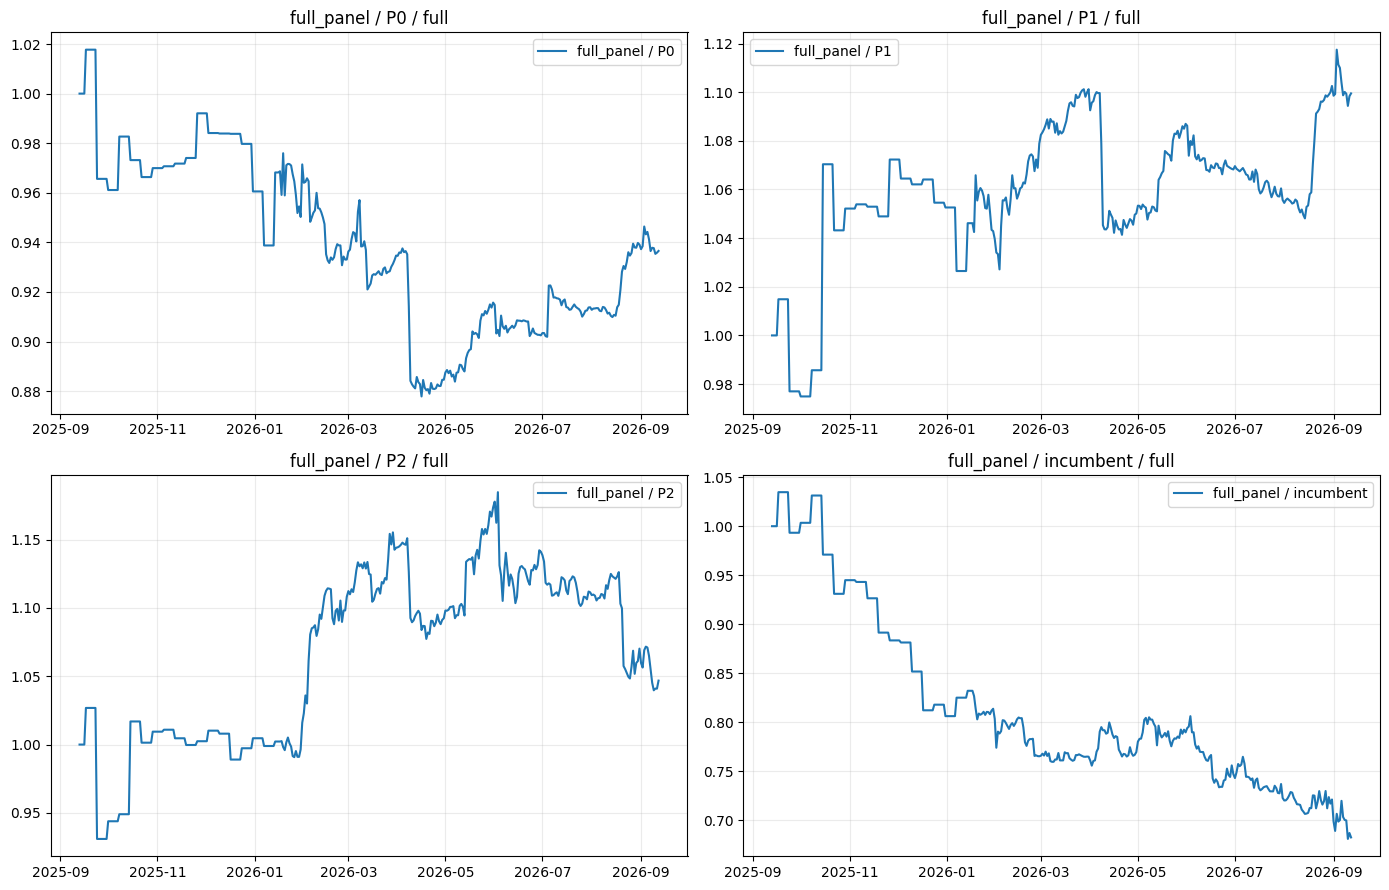

In [6]:
report = {
    "notebook": "11-research-profitability-repeatability.ipynb",
    "selection_windows_days": list(WINDOWS),
    "arms": list(ARMS),
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "max_names": MAX_NAMES,
    "target_deployment": TARGET_DEPLOYMENT,
    "max_weight": MAX_WEIGHT,
    "max_tvl_fraction": MAX_TVL_FRACTION,
    "execution_every_days": EXECUTION_EVERY_DAYS,
    "initial_cash": INITIAL_CASH,
    "a0b_allowlist_count": len(A0B_ALLOWLIST),
    "full_panel_count": len(UNIVERSES["full_panel"]),
    "blocked_metadata_count": len(BLOCKED),
    "fees": "none added; share-price NAV is the observable input",
    "survivorship_warning": "A0b allowlist is a retrospective current snapshot; full-panel comparison is required",
    "p2_missing_repeatability_policy": "missing weekly outcomes remain provisional and do not pass P2",
    "point_in_time_rule": "metrics use observations at or before last_observation_ts; labels are not read by selection",
    "backtest_metrics": backtest_metrics.to_dict(orient="records"),
    "forward_rows": len(forward_diagnostics),
}
(OUT / "nb11-report.json").write_text(json.dumps(report, indent=2, default=str))
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for axis, ((universe_name, arm), selection) in zip(axes.flat, list(SELECTIONS.items())[:4]):
    curve_path = OUT / f"equity-{universe_name}-{arm}-full.parquet"
    curve = pd.read_parquet(curve_path)
    axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=f"{universe_name} / {arm}")
    axis.set_title(f"{universe_name} / {arm} / full")
    axis.grid(alpha=.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "profitability-repeatability-equity-curves.png", dpi=130)
plt.show()
